Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
y = 1.6750779365919648 x + 14.034674430915832
R^2 =  0.30309811482575927
Average error% =  23.490869923070452 %
Root mean squared error =  6.75881211766326 %


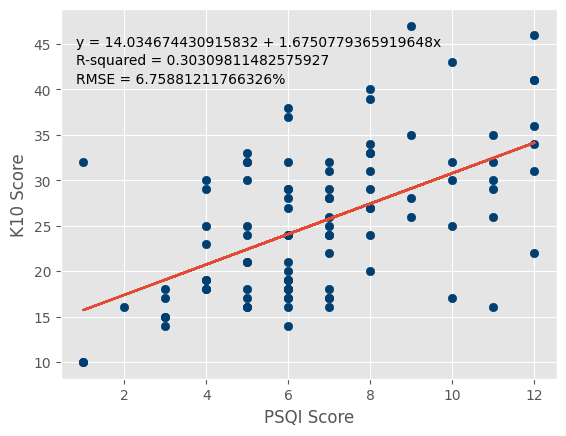

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
file_path = '/content/drive/MyDrive/School/Probes/Sleep and Stress Questionnaire (Responses).xlsx'
df = pd.read_excel(file_path)

def point():
    global number
    global points
    global row
    global rows
    global total
    global columns
    global column
    while True:
        if df.iat[row, column] == "None of the time":
            option = "A"
        elif df.iat[row, column] == "A little of the time":
            option = "B"
        elif df.iat[row, column] == "Some of the time":
            option = "C"
        elif df.iat[row, column] == "Most of the time":
            option = "D"
        elif df.iat[row, column] == "All of the time":
            option = "E"
        if option == "A" or option == "a":
            points = points+1
            number=number+1
            break
        elif option == "B" or option == "b":
            points = points+2
            number=number+1
            break
        elif option == "C" or option == "c":
            points = points+3
            number=number+1
            break
        elif option == "D" or option == "d":
            points = points+4
            number=number+1
            break
        elif option == "E" or option =="e":
            points = points+5
            number=number+1
            break
def calculate():
    global number
    global points
    global row
    global rows
    global columns
    global total
    global count
    global column
    while column<columns:
        point()
        column=column+1
    total.append(points)

rows = len(df.axes[0])
columns = len(df.axes[1])
row = 0
column=21
count=0
number=0
points=0
total=[]
while row<rows:
    calculate()
    row=row+1
    count=count+1
    points=0
    number=0
    column=21


def convert24(str1):
    if str1[-2:] == "AM" and str1[:2] == "12":
        return "00" + str1[2:-2]
    elif str1[-2:] == "AM":
        return str1[:-2]
    elif str1[-2:] == "PM" and str1[:2] == "12":
        return str1[:-2]
    else:
        return str(int(str1[:2]) + 12) + str1[2:8]

def convert24(str2):
    if str2[-2:] == "AM" and str2[:2] == "12":
        return "00" + str1[2:-2]
    elif str2[-2:] == "AM":
        return str1[:-2]
    elif str2[-2:] == "PM" and str2[:2] == "12":
        return str1[:-2]
    else:
        return str(int(str2[:2]) + 12) + str2[2:8]
def one():
    global scoreone
    if df.iat[row, 17] == "Very good":
        scoreone = 0
    elif df.iat[row, 17] == "Fairly good":
        scoreone = 1
    elif df.iat[row, 17] == "Fairly bad":
            scoreone = 2
    elif df.iat[row, 17] == "Very bad":
        scoreone = 3
def two():
    global scoretwo
    if df.iat[row, 5] <= 15:
        scoretwo = scoretwo+0
    elif df.iat[row, 5] <= 30:
        scoretwo = scoretwo+1
    elif df.iat[row, 5] <= 60:
        scoretwo = scoretwo+2
    elif df.iat[row, 5] > 60:
        scoretwo = scoretwo+3
    if df.iat[row, 8] == "None":
        scoretwo = scoretwo+0
    elif df.iat[row, 8] == "Less than once a week":
        scoretwo = scoretwo+1
    elif df.iat[row, 8] == "Once or twice a week":
        scoretwo = scoretwo+2
    elif df.iat[row, 8] == "Three or more times a week":
        scoretwo = scoretwo+3
    if scoretwo == 0:
        scoretwo = 0
    elif scoretwo <= 2:
        scoretwo = 1
    elif scoretwo <= 4:
        scoretwo = 2
    elif scoretwo <= 6:
        scoretwo = 3
def three():
    global scorethree
    if df.iat[row, 7] > 7:
        scorethree = scorethree+0
    elif df.iat[row, 7] >=6:
        scorethree = scorethree+1
    elif df.iat[row, 7] >=5:
        scorethree = scorethree+2
    elif df.iat[row, 7] <5:
        scorethree = scorethree+3

def four():
    global scorefour
    global str1
    global str2
    str1=df.iat[row, 6]
    str2=df.iat[row, 4]
    if (int(str2.strftime("%H"))+(int(str2.strftime("%M"))/60)+(int(str2.strftime("%S"))/3600)) >=18:
        if df.iat[row, 7]/(abs(int(str1.strftime("%H"))+(int(str1.strftime("%M"))/60)+(int(str1.strftime("%S"))/3600)+12)-abs(int(str2.strftime("%H"))+(int(str2.strftime("%M"))/60)+(int(str2.strftime("%S"))/3600)-12))*100 > 85:
            scorefour = scorefour+0
        elif df.iat[row, 7]/(abs(int(str1.strftime("%H"))+(int(str1.strftime("%M"))/60)+(int(str1.strftime("%S"))/3600)+12)-abs(int(str2.strftime("%H"))+(int(str2.strftime("%M"))/60)+(int(str2.strftime("%S"))/3600)-12))*100 >= 75:
            scorefour = scorefour+1
        elif df.iat[row, 7]/(abs(int(str1.strftime("%H"))+(int(str1.strftime("%M"))/60)+(int(str1.strftime("%S"))/3600)+12)-abs(int(str2.strftime("%H"))+(int(str2.strftime("%M"))/60)+(int(str2.strftime("%S"))/3600)-12))*100 >= 65:
            scorefour = scorefour+2
        elif df.iat[row, 7]/(abs(int(str1.strftime("%H"))+(int(str1.strftime("%M"))/60)+(int(str1.strftime("%S"))/3600)+12)-abs(int(str2.strftime("%H"))+(int(str2.strftime("%M"))/60)+(int(str2.strftime("%S"))/3600)-12))*100 < 65:
            scorefour = scorefour+3
    elif (int(str2.strftime("%H"))+(int(str2.strftime("%M"))/60)+(int(str2.strftime("%S"))/3600)) >5.5:
        if df.iat[row, 7]/(abs(int(str1.strftime("%H"))+(int(str1.strftime("%M"))/60)+(int(str1.strftime("%S"))/3600)+12)-abs(int(str2.strftime("%H"))+(int(str2.strftime("%M"))/60)+(int(str2.strftime("%S"))/3600)))*100 > 85:
            scorefour = scorefour+0
        elif df.iat[row, 7]/(abs(int(str1.strftime("%H"))+(int(str1.strftime("%M"))/60)+(int(str1.strftime("%S"))/3600)+12)-abs(int(str2.strftime("%H"))+(int(str2.strftime("%M"))/60)+(int(str2.strftime("%S"))/3600)))*100 >= 75:
            scorefour = scorefour+1
        elif df.iat[row, 7]/(abs(int(str1.strftime("%H"))+(int(str1.strftime("%M"))/60)+(int(str1.strftime("%S"))/3600)+12)-abs(int(str2.strftime("%H"))+(int(str2.strftime("%M"))/60)+(int(str2.strftime("%S"))/3600)))*100 >= 65:
            scorefour = scorefour+2
        elif df.iat[row, 7]/(abs(int(str1.strftime("%H"))+(int(str1.strftime("%M"))/60)+(int(str1.strftime("%S"))/3600)+12)-abs(int(str2.strftime("%H"))+(int(str2.strftime("%M"))/60)+(int(str2.strftime("%S"))/3600)))*100 < 65:
            scorefour = scorefour+3
    else:
        if df.iat[row, 7]/(abs(int(str1.strftime("%H"))+(int(str1.strftime("%M"))/60)+(int(str1.strftime("%S"))/3600))-abs(int(str2.strftime("%H"))+(int(str2.strftime("%M"))/60)+(int(str2.strftime("%S"))/3600)))*100 > 85:
            scorefour = scorefour+0
        elif df.iat[row, 7]/(abs(int(str1.strftime("%H"))+(int(str1.strftime("%M"))/60)+(int(str1.strftime("%S"))/3600))-abs(int(str2.strftime("%H"))+(int(str2.strftime("%M"))/60)+(int(str2.strftime("%S"))/3600)))*100 >= 75:
            scorefour = scorefour+1
        elif df.iat[row, 7]/(abs(int(str1.strftime("%H"))+(int(str1.strftime("%M"))/60)+(int(str1.strftime("%S"))/3600))-abs(int(str2.strftime("%H"))+(int(str2.strftime("%M"))/60)+(int(str2.strftime("%S"))/3600)))*100 >= 65:
            scorefour = scorefour+2
        elif df.iat[row, 7]/(abs(int(str1.strftime("%H"))+(int(str1.strftime("%M"))/60)+(int(str1.strftime("%S"))/3600))-abs(int(str2.strftime("%H"))+(int(str2.strftime("%M"))/60)+(int(str2.strftime("%S"))/3600)))*100 < 65:
            scorefour = scorefour+3
def five():
    global scorefive
    if df.iat[row, 9] == "None":
        scorefive = scorefive+0
    elif df.iat[row, 9] == "Less than once a week":
        scorefive = scorefive+1
    elif df.iat[row, 9] == "Once or twice a week":
        scorefive = scorefive+2
    elif df.iat[row, 9] == "Three or more times a week":
        scorefive = scorefive+3
    if df.iat[row, 10] == "None":
        scorefive = scorefive+0
    elif df.iat[row, 10] == "Less than once a week":
        scorefive = scorefive+1
    elif df.iat[row, 10] == "Once or twice a week":
        scorefive = scorefive+2
    elif df.iat[row, 10] == "Three or more times a week":
        scorefive = scorefive+3
    if df.iat[row, 11] == "None":
        scorefive = scorefive+0
    elif df.iat[row, 11] == "Less than once a week":
        scorefive = scorefive+1
    elif df.iat[row, 11] == "Once or twice a week":
        scorefive = scorefive+2
    elif df.iat[row, 11] == "Three or more times a week":
        scorefive = scorefive+3
    if df.iat[row, 12] == "None":
        scorefive = scorefive+0
    elif df.iat[row, 12] == "Less than once a week":
        scorefive = scorefive+1
    elif df.iat[row, 12] == "Once or twice a week":
        scorefive = scorefive+2
    elif df.iat[row, 12] == "Three or more times a week":
        scorefive = scorefive+3
    if df.iat[row, 13] == "None":
        scorefive = scorefive+0
    elif df.iat[row, 13] == "Less than once a week":
        scorefive = scorefive+1
    elif df.iat[row, 13] == "Once or twice a week":
        scorefive = scorefive+2
    elif df.iat[row, 13] == "Three or more times a week":
        scorefive = scorefive+3
    if df.iat[row, 14] == "None":
        scorefive = scorefive+0
    elif df.iat[row, 14] == "Less than once a week":
        scorefive = scorefive+1
    elif df.iat[row, 14] == "Once or twice a week":
        scorefive = scorefive+2
    elif df.iat[row, 14] == "Three or more times a week":
        scorefive = scorefive+3
    if df.iat[row, 15] == "None":
        scorefive = scorefive+0
    elif df.iat[row, 15] == "Less than once a week":
        scorefive = scorefive+1
    elif df.iat[row, 15] == "Once or twice a week":
        scorefive = scorefive+2
    elif df.iat[row, 15] == "Three or more times a week":
        scorefive = scorefive+3
    if df.iat[row, 16] == "None":
        scorefive = scorefive+0
    elif df.iat[row, 16] == "Less than once a week":
        scorefive = scorefive+1
    elif df.iat[row, 16] == "Once or twice a week":
        scorefive = scorefive+2
    elif df.iat[row, 16] == "Three or more times a week":
        scorefive = scorefive+3
    if scorefive == 0:
        scorefive = 0
    elif scorefive <= 9:
        scorefive = 1
    elif scorefive <= 18:
        scorefive = 2
    elif scorefive <= 27:
        scorefive = 3

def six():
    global scoresix
    if df.iat[row, 18] == "None":
        scoresix = scoresix+0
    elif df.iat[row, 18] == "Less than once a week":
        scoresix = scoresix+1
    elif df.iat[row, 18] == "Once or twice a week":
        scoresix = scoresix+2
    elif df.iat[row, 18] == "Three or more times a week":
        scoresix = scoresix+3

def seven():
    global scoreseven
    if df.iat[row, 19] == "None":
        scoreseven = scoreseven+0
    elif df.iat[row, 19] == "Less than once a week":
        scoreseven = scoreseven+1
    elif df.iat[row, 19] == "Once or twice a week":
        scoreseven = scoreseven+2
    elif df.iat[row, 19] == "Three or more times a week":
        scoreseven = scoreseven+3
    if df.iat[row, 20] == "No problem at all":
        scoreseven = scoreseven+0
    elif df.iat[row, 20] == "Only a very slight problem":
        scoreseven = scoreseven+1
    elif df.iat[row, 20] == "Somewhat of a problem":
        scoreseven = scoreseven+2
    elif df.iat[row, 20] == "A very big problem":
        scoreseven = scoreseven+3
    if scoreseven == 0:
        scoreseven = 0
    elif scoreseven <= 2:
        scoreseven = 1
    elif scoreseven <= 4:
        scoreseven = 2
    elif scoreseven <= 6:
        scoreseven = 3

rows = len(df.axes[0])
row = 0
scoreone=0
scoretwo=0
scorethree=0
scorefour=0
scorefive=0
scoresix=0
scoreseven=0
str1=0
str2=0
totalpsqi=[]

while row<rows:
    one()
    two()
    three()
    four()
    five()
    six()
    seven()
    row=row+1
    score=scoreone+scoretwo+scorethree+scorefour+scorefive+scoresix+scoreseven
    totalpsqi.append(score)
    scoreone=0
    scoretwo=0
    scorethree=0
    scorefour=0
    scorefive=0
    scoresix=0
    scoreseven=0
    str1=0
    str2=0

import numpy as np
import numpy
Q1p = int(np.quantile(numpy.array(totalpsqi), .25))
Q3p = int(np.quantile(numpy.array(totalpsqi), .75))
IQRp = Q3p - Q1p
lowerp = Q1p - 1.5*IQRp
upperp = Q3p + 1.5*IQRp
Q1k = int(np.quantile(numpy.array(total), .25))
Q3k = int(np.quantile(numpy.array(total), .75))
IQRk = Q3k - Q1k
lowerk = Q1k - 1.5*IQRk
upperk = Q3k + 1.5*IQRk

outlierp=[]
for x in range(0,len(totalpsqi)):
    if totalpsqi[x]>=upperp or totalpsqi[x]<=lowerp:
        element_to_appendp = totalpsqi[x]
        outlierp.append(element_to_appendp)

outlierk=[]
for y in range(0,len(total)):
    if total[y]>=upperk or total[y]<=lowerk:
        element_to_appendk = total[y]
        outlierk.append(element_to_appendk)

list=[]
for i in range(0,rows):
    list.append([totalpsqi[i],total[i]])
list=[elem for elem in list if (elem[0] not in outlierp) and (elem[1] not in outlierk)]

from statistics import mean

data1 = [item[0] for item in list]
data2 = [item[1] for item in list]

xs = np.array(data1, dtype=np.float64)
ys = np.array(data2, dtype=np.float64)

def best_fit_slope_and_intercept(xs,ys):
    m = (((mean(xs)*mean(ys)) - mean(xs*ys)) /
         ((mean(xs)*mean(xs)) - mean(xs*xs)))

    b = mean(ys) - m*mean(xs)

    return m, b

m, b = best_fit_slope_and_intercept(xs,ys)

regression_line = [(m*x)+b for x in xs]

print("y =",m,"x +",b)

correlation_matrix = np. corrcoef(xs, ys)
correlation_xy = correlation_matrix[0,1]
r_squared = correlation_xy**2.
print("R^2 = ",r_squared)

import matplotlib.pyplot as plt
from matplotlib import style
import math
style.use('ggplot')

plt.scatter(xs,ys,color='#003F72')
plt.plot(xs, regression_line)
plt.text(0.03, 0.85, f'R-squared = {r_squared}', fontsize=10, transform=plt.gca().transAxes)
equation = f'y = {b} + {m}x'
plt.text(0.03, 0.9, equation, fontsize=10, transform=plt.gca().transAxes)

y_predicted=[]
error=[]
for i in range(0,len(xs)):
    error.append(abs((m*xs[i]+b)-ys[i])/ys[i]*100)
    y_predicted.append(m*xs[i]+b)
MSE = np.square(np.subtract(ys,y_predicted)).mean()
RMSE = math.sqrt(MSE)
mean = sum(error) / len(error)
print("Average error% = ",mean,"%")
print("Root mean squared error = ",RMSE,"%")
plt.xlabel("PSQI Score")
plt.ylabel("K10 Score")
plt.text(0.03, 0.8, f'RMSE = {RMSE}%', fontsize=10, transform=plt.gca().transAxes)
plt.show()